# Join và tính toán các metrics

In [1]:
from pathlib import Path
import pandas as pd, json

def read_folder(path="data/cleaned"):
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"{path} does not exist")
    files = sorted([f for f in p.iterdir() if f.is_file()])
    out = {}

    for f in files:
        suf = f.suffix.lower()
        if suf in (".csv", ".tsv"):
            sep = "\t" if suf == ".tsv" else ","
            out[f.name] = pd.read_csv(f, sep=sep)
        elif suf in (".parquet",):
            out[f.name] = pd.read_parquet(f)
        elif suf == ".json":
            try:
                out[f.name] = pd.read_json(f, lines=True)
            except ValueError:
                with f.open("r", encoding="utf8") as fh:
                    out[f.name] = json.load(fh)
        elif suf == ".txt":
            out[f.name] = f.read_text(encoding="utf8")
        else:
            out[f.name] = f.read_bytes()

    print(f"Read {len(out)} files from {path}: {', '.join(out.keys())}")
    return out

# Example usage:
# data = read_folder("data/cleaned")

In [2]:
folder = Path("data/cleaned")
csv_files = sorted(folder.glob("*.csv"))[:6]

if len(csv_files) < 6:
    raise FileNotFoundError(f"Found only {len(csv_files)} CSV files in {folder}")

data = {f.name: pd.read_csv(f) for f in csv_files}
print("Read CSV files:", list(data.keys()))

Read CSV files: ['cleaned_customers.csv', 'cleaned_items.csv', 'cleaned_orders.csv', 'cleaned_payments.csv', 'cleaned_products.csv', 'cleaned_sellers.csv']


In [3]:
df_customers = data['cleaned_customers.csv']
df_items = data['cleaned_items.csv']
df_orders = data['cleaned_orders.csv']
df_payments = data['cleaned_payments.csv']
df_products = data['cleaned_products.csv']

In [4]:
df_orders = df_orders[df_orders['order_status'] == 'delivered']

In [5]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


# Join các bảng lại với nhau

In [6]:
df_merge = df_customers.merge(
    df_orders,
    on="customer_id",
    how="left"
)
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05


In [7]:
df_merge = df_merge[df_merge['order_status'] == 'delivered']
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05


In [8]:
# Nếu có mode duy nhất -> dùng mode
# Nếu không có mode rõ ràng (nhiều mode) -> dùng last

def mode_or_last(x):
    modes = x.mode()

    # chỉ có 1 mode duy nhất
    if len(modes) == 1:
        return modes.iloc[0]

    # nhiều mode hoặc không có mode rõ ràng -> lấy last
    return x.iloc[-1]


olist_customers = (
    df_merge
    .groupby("customer_unique_id")
    .agg(
        frequency=("customer_id", "count"),

        customer_zip_code_prefix=(
            "customer_zip_code_prefix",
            mode_or_last
        ),

        customer_city=(
            "customer_city",
            mode_or_last
        ),

        customer_state=(
            "customer_state",
            mode_or_last
        ),
    )
    .reset_index()
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP
...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES


In [9]:
# Đảm bảo datetime
df_merge["order_purchase_timestamp"] = pd.to_datetime(
    df_merge["order_purchase_timestamp"]
)

# Ngày tham chiếu = ngày mua hàng mới nhất + 1 ngày
reference_date = (
    df_merge["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

# Tính recency theo customer_unique_id
recency_df = (
    df_merge
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .max()
    .reset_index()
)

recency_df["recency"] = (
    reference_date - recency_df["order_purchase_timestamp"]
).dt.days

# Chỉ giữ cột cần thiết
recency_df = recency_df[
    ["customer_unique_id", "recency"]
]

# Join vào olist_customers
olist_customers = olist_customers.merge(
    recency_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288
...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119


In [10]:
df_merge = df_merge.merge(
    df_payments,
    on="order_id",
    how="left"
)

In [11]:
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1.0,credit_card,8.0,252.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100752,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,1.0,credit_card,6.0,88.78
100753,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,1.0,credit_card,3.0,129.06
100754,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,credit_card,5.0,56.04
100755,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,1.0,credit_card,2.0,711.07


In [12]:
# Tính Monetary theo customer_unique_id
# Monetary = tổng payment_value của khách hàng

monetary_df = (
    df_merge
    .groupby("customer_unique_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "monetary"})
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    monetary_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89
...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69


In [13]:
df_merge = df_merge.merge(
    df_items,
    on="order_id",
    how="left"
)
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,credit_card,2.0,146.87,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1.0,credit_card,8.0,335.48,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1.0,credit_card,7.0,157.73,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1.0,credit_card,1.0,173.30,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1.0,credit_card,8.0,252.25,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115033,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,1.0,credit_card,6.0,88.78,1,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88
115034,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,1.0,credit_card,3.0,129.06,1,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16
115035,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,1.0,credit_card,5.0,56.04,1,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04
115036,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,1.0,credit_card,2.0,711.07,1,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-09 21:15:51,689.00,22.07


In [14]:
# Tính total_item theo customer_unique_id
# = tổng số item đã mua (đếm order_item_id)

total_item_df = (
    df_merge
    .groupby("customer_unique_id")["order_item_id"]
    .count()
    .reset_index()
    .rename(columns={"order_item_id": "total_item"})
)

olist_customers = olist_customers.merge(
    total_item_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1
...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1


In [15]:
df_merge = df_merge.merge(
    df_products,
    on="product_id",
    how="left"
)
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,124.99,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,289.00,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,139.94,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,149.94,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,230.00,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115033,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,74.90,13.88,livros_interesse_geral,51.0,489.0,2.0,611.0,22.0,22.0,23.0
115034,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,114.90,14.16,esporte_lazer,51.0,1193.0,1.0,1211.0,25.0,24.0,22.0
115035,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,37.00,19.04,beleza_saude,60.0,575.0,1.0,870.0,25.0,20.0,18.0
115036,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,689.00,22.07,relogios_presentes,59.0,452.0,1.0,710.0,19.0,13.0,14.0


In [16]:
pd.set_option("display.max_columns", None)

In [17]:
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1.0,credit_card,2.0,146.87,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1.0,credit_card,8.0,335.48,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1.0,credit_card,7.0,157.73,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0,credit_card,1.0,173.30,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1.0,credit_card,8.0,252.25,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115033,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,1.0,credit_card,6.0,88.78,1,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88,livros_interesse_geral,51.0,489.0,2.0,611.0,22.0,22.0,23.0
115034,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,1.0,credit_card,3.0,129.06,1,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16,esporte_lazer,51.0,1193.0,1.0,1211.0,25.0,24.0,22.0
115035,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,credit_card,5.0,56.04,1,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04,beleza_saude,60.0,575.0,1.0,870.0,25.0,20.0,18.0
115036,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120

In [18]:
# Tính số lượng category unique mà customer đã mua

unique_category_df = (
    df_merge
    .groupby("customer_unique_id")["product_category_name"]
    .nunique()
    .reset_index()
    .rename(columns={
        "product_category_name": "unique_category"
    })
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    unique_category_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1
...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1


In [19]:
# Favorite category:
# - Nếu có 1 mode duy nhất -> dùng mode
# - Nếu nhiều mode -> dùng category mua gần nhất (last)

# Sắp xếp theo thời gian trước
df_merge = df_merge.sort_values(
    by=["customer_unique_id", "order_purchase_timestamp"]
)

def mode_or_last(x):
    modes = x.mode()

    # có 1 mode duy nhất
    if len(modes) == 1:
        return modes.iloc[0]

    # nhiều mode -> lấy last
    return x.iloc[-1]

favorite_category_df = (
    df_merge
    .groupby("customer_unique_id")["product_category_name"]
    .agg(mode_or_last)
    .reset_index()
    .rename(columns={
        "product_category_name": "favorite_category"
    })
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    favorite_category_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1,beleza_saude
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1,papelaria
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1,telefonia
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1,telefonia
...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1,bebes
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1,automotivo
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes


In [20]:
# payment_type_diversity
# = số lượng payment_type khác nhau mà customer đã dùng

payment_type_diversity_df = (
    df_merge
    .groupby("customer_unique_id")["payment_type"]
    .nunique()
    .reset_index()
    .rename(columns={
        "payment_type": "payment_type_diversity"
    })
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    payment_type_diversity_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1,telefonia,1
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1
...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1,automotivo,1
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1


In [21]:
# dominant_payment_type
# - Nếu có 1 mode duy nhất -> dùng mode
# - Nếu nhiều mode -> dùng payment_type gần nhất (last)

# Sort theo thời gian mua
df_merge = df_merge.sort_values(
    by=["customer_unique_id", "order_purchase_timestamp"]
)

def mode_or_last(x):
    modes = x.mode()

    # có 1 mode duy nhất
    if len(modes) == 1:
        return modes.iloc[0]

    # nhiều mode -> lấy last
    return x.iloc[-1]

dominant_payment_type_df = (
    df_merge
    .groupby("customer_unique_id")["payment_type"]
    .agg(mode_or_last)
    .reset_index()
    .rename(columns={
        "payment_type": "dominant_payment_type"
    })
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    dominant_payment_type_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card
...,...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card


In [22]:
import pandas as pd

# Convert datetime
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_merge[col] = pd.to_datetime(df_merge[col])

# ===== DELIVERY FEATURES =====

# Số ngày giao hàng thực tế
df_merge["delivery_days"] = (
    df_merge["order_delivered_customer_date"]
    - df_merge["order_purchase_timestamp"]
).dt.days

# Delay giao hàng
# > 0 : giao trễ
# < 0 : giao sớm
df_merge["shipping_delay"] = (
    df_merge["order_delivered_customer_date"]
    - df_merge["order_estimated_delivery_date"]
).dt.days

# ===== CUSTOMER LEVEL =====

delivery_features_df = (
    df_merge
    .groupby("customer_unique_id")
    .agg(
        avg_delivery_days=("delivery_days", "mean"),
        avg_shipping_delay=("shipping_delay", "mean"),
    )
    .reset_index()
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    delivery_features_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card,27.0,-27.0
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card,30.0,-3.0
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card,14.0,-30.0
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card,11.0,-14.0


In [23]:
import pandas as pd

# ===== DATETIME =====
date_cols = [
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_merge[col] = pd.to_datetime(df_merge[col])

# ===== LATE DELIVERY =====
# 1 = giao trễ
df_merge["is_late_delivery"] = (
    df_merge["order_delivered_customer_date"]
    > df_merge["order_estimated_delivery_date"]
).astype(int)

# ===== FREIGHT RATIO =====
# freight / total_value_item
df_merge["freight_ratio"] = (
    df_merge["freight_value"]
    / (df_merge["price"] + df_merge["freight_value"])
)

# ===== CUSTOMER LEVEL =====
delivery_cost_df = (
    df_merge
    .groupby("customer_unique_id")
    .agg(
        late_delivery_ratio=("is_late_delivery", "mean"),
        avg_freight_ratio=("freight_ratio", "mean"),
    )
    .reset_index()
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    delivery_cost_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0,0.0,0.084567
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0,0.0,0.304892
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0,0.0,0.199722
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0,0.0,0.404172
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0,0.0,0.085784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card,27.0,-27.0,0.0,0.242553
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card,30.0,-3.0,0.0,0.232797
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card,14.0,-30.0,0.0,0.200605
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card,11.0,-14.0,0.0,0.139801


In [24]:
import pandas as pd

# ===== DATETIME =====
date_cols = [
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "order_delivered_customer_date"
]

for col in date_cols:
    df_merge[col] = pd.to_datetime(df_merge[col])

# ===== FEATURE ENGINEERING =====

# Freight value trung bình
df_merge["freight_value"] = pd.to_numeric(
    df_merge["freight_value"],
    errors="coerce"
)

# Estimated gap:
# số ngày dự kiến giao kể từ lúc mua
df_merge["estimated_gap"] = (
    df_merge["order_estimated_delivery_date"]
    - df_merge["order_purchase_timestamp"]
).dt.days

# ===== CUSTOMER LEVEL =====

delivery_features_df = (
    df_merge
    .groupby("customer_unique_id")
    .agg(
        avg_freight_value=("freight_value", "mean"),

        avg_estimated_gap=("estimated_gap", "mean"),
    )
    .reset_index()
)

# Join vào olist_customers
olist_customers = olist_customers.merge(
    delivery_features_df,
    on="customer_unique_id",
    how="left"
)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0,0.0,0.084567,12.00,10.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0,0.0,0.304892,8.29,7.0
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0,0.0,0.199722,17.22,27.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0,0.0,0.404172,17.63,31.0
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0,0.0,0.085784,16.89,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card,27.0,-27.0,0.0,0.242553,248.71,54.0
93354,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card,30.0,-3.0,0.0,0.232797,19.69,32.0
93355,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card,14.0,-30.0,0.0,0.200605,22.56,44.0
93356,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card,11.0,-14.0,0.0,0.139801,18.69,25.0


In [25]:
olist_customers.isnull().sum()

customer_unique_id          0
frequency                   0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
recency                     0
monetary                    0
total_item                  0
unique_category             0
favorite_category           0
payment_type_diversity      0
dominant_payment_type       1
avg_delivery_days           0
avg_shipping_delay          0
late_delivery_ratio         0
avg_freight_ratio           0
avg_freight_value           0
avg_estimated_gap           0
dtype: int64

dominant_payment_type missing là do không có payment hướng xử lý drop

In [32]:
olist_customers[
    olist_customers["dominant_payment_type"].isnull()
]

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
47882,830d5b7aaa3b6f1e9ad63703bec97d23,1,14600,sao joaquim da barra,SP,714,0.0,3,1,beleza_saude,0,NaN,54.0,36.0,1.0,0.05918,2.83,18.0


In [33]:
df_customers[df_customers["customer_unique_id"]=='830d5b7aaa3b6f1e9ad63703bec97d23']

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
21125,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP


In [34]:
df_orders[df_orders["customer_id"]=='86dc2ffce2dfff336de2f386a786e574']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04


In [35]:
df_payments[df_payments['order_id']=='bfbd0f9bdef84302105ad712db648a6c']

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [36]:
olist_customers = olist_customers[
    ~olist_customers["dominant_payment_type"].isnull()
].reset_index(drop=True)

olist_customers

,customer_unique_id,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
0,0000366f3b9a7992bf8c76cfdf3221e2,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0,0.0,0.084567,12.00,10.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0,0.0,0.304892,8.29,7.0
2,0000f46a3911fa3c0805444483337064,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0,0.0,0.199722,17.22,27.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0,0.0,0.404172,17.63,31.0
4,0004aac84e0df4da2b147fca70cf8255,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0,0.0,0.085784,16.89,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card,27.0,-27.0,0.0,0.242553,248.71,54.0
93353,fffea47cd6d3cc0a88bd621562a9d061,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card,30.0,-3.0,0.0,0.232797,19.69,32.0
93354,ffff371b4d645b6ecea244b27531430a,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card,14.0,-30.0,0.0,0.200605,22.56,44.0
93355,ffff5962728ec6157033ef9805bacc48,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card,11.0,-14.0,0.0,0.139801,18.69,25.0


In [38]:
olist_customers = olist_customers.drop(
    columns=["customer_unique_id"]
)

olist_customers

,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
0,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0,0.0,0.084567,12.00,10.0
1,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0,0.0,0.304892,8.29,7.0
2,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0,0.0,0.199722,17.22,27.0
3,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0,0.0,0.404172,17.63,31.0
4,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0,0.0,0.085784,16.89,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93352,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card,27.0,-27.0,0.0,0.242553,248.71,54.0
93353,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card,30.0,-3.0,0.0,0.232797,19.69,32.0
93354,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card,14.0,-30.0,0.0,0.200605,22.56,44.0
93355,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card,11.0,-14.0,0.0,0.139801,18.69,25.0


In [39]:
olist_customers[
    olist_customers.duplicated(keep=False)
]

,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
15197,1,80030,curitiba,PR,602,19.62,1,1,fashion_bolsas_e_acessorios,1,boleto,11.0,-16.0,0.0,0.444444,8.72,26.0
39802,1,38660,buritis,MG,324,41.09,1,1,telefonia,1,credit_card,8.0,-14.0,0.0,0.367486,15.10,21.0
64641,1,38660,buritis,MG,324,41.09,1,1,telefonia,1,credit_card,8.0,-14.0,0.0,0.367486,15.10,21.0
66712,1,80030,curitiba,PR,602,19.62,1,1,fashion_bolsas_e_acessorios,1,boleto,11.0,-16.0,0.0,0.444444,8.72,26.0
75109,1,2534,sao paulo,SP,108,876.82,1,1,portateis_casa_forno_e_cafe,1,credit_card,2.0,-13.0,0.0,0.020437,17.92,14.0
81941,1,2534,sao paulo,SP,108,876.82,1,1,portateis_casa_forno_e_cafe,1,credit_card,2.0,-13.0,0.0,0.020437,17.92,14.0


In [40]:
# Drop duplicate rows

olist_customers = olist_customers.drop_duplicates()

# Reset index nếu muốn
olist_customers = olist_customers.reset_index(drop=True)

In [41]:
olist_customers

,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
0,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0,0.0,0.084567,12.00,10.0
1,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0,0.0,0.304892,8.29,7.0
2,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0,0.0,0.199722,17.22,27.0
3,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0,0.0,0.404172,17.63,31.0
4,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0,0.0,0.085784,16.89,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93349,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card,27.0,-27.0,0.0,0.242553,248.71,54.0
93350,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card,30.0,-3.0,0.0,0.232797,19.69,32.0
93351,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card,14.0,-30.0,0.0,0.200605,22.56,44.0
93352,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card,11.0,-14.0,0.0,0.139801,18.69,25.0


In [42]:
out_dir = "data/cleaned"

import os
os.makedirs(out_dir, exist_ok=True)

olist_customers.to_csv(
    f"{out_dir}/olist_customers.csv",
    index=False
)

# Check data type

In [43]:
olist_customers.dtypes

frequency                     int64
customer_zip_code_prefix      int64
customer_city                   str
customer_state                  str
recency                       int64
monetary                    float64
total_item                    int64
unique_category               int64
favorite_category               str
payment_type_diversity        int64
dominant_payment_type           str
avg_delivery_days           float64
avg_shipping_delay          float64
late_delivery_ratio         float64
avg_freight_ratio           float64
avg_freight_value           float64
avg_estimated_gap           float64
dtype: object

In [44]:
olist_customers.isnull().sum()

frequency                   0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
recency                     0
monetary                    0
total_item                  0
unique_category             0
favorite_category           0
payment_type_diversity      0
dominant_payment_type       0
avg_delivery_days           0
avg_shipping_delay          0
late_delivery_ratio         0
avg_freight_ratio           0
avg_freight_value           0
avg_estimated_gap           0
dtype: int64

# Univaritate

## Category

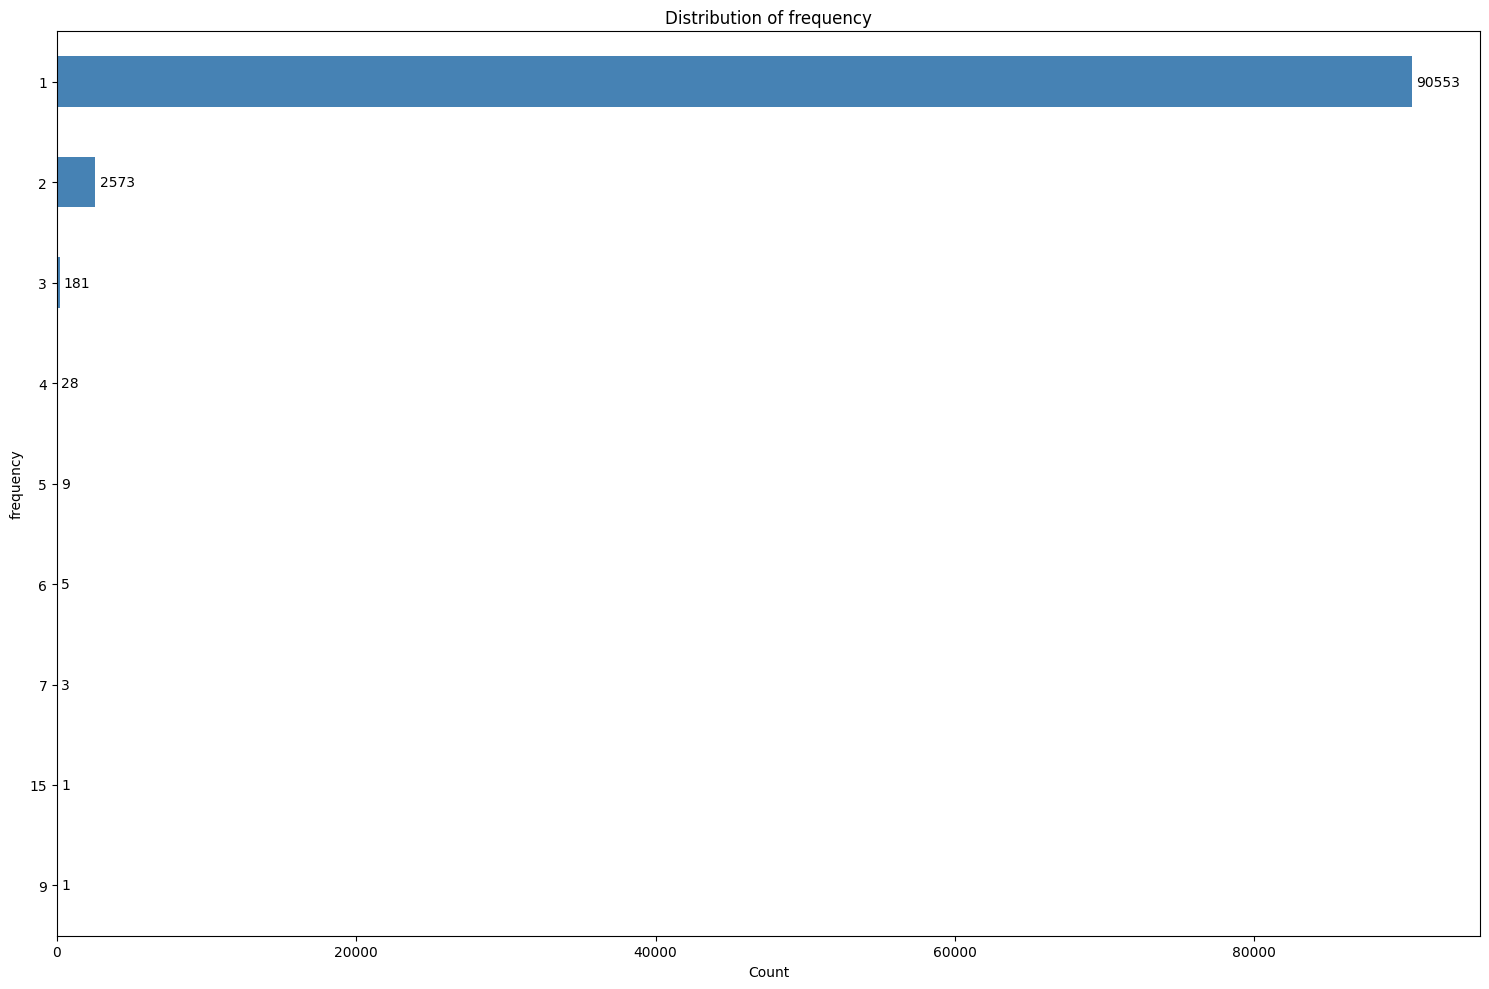

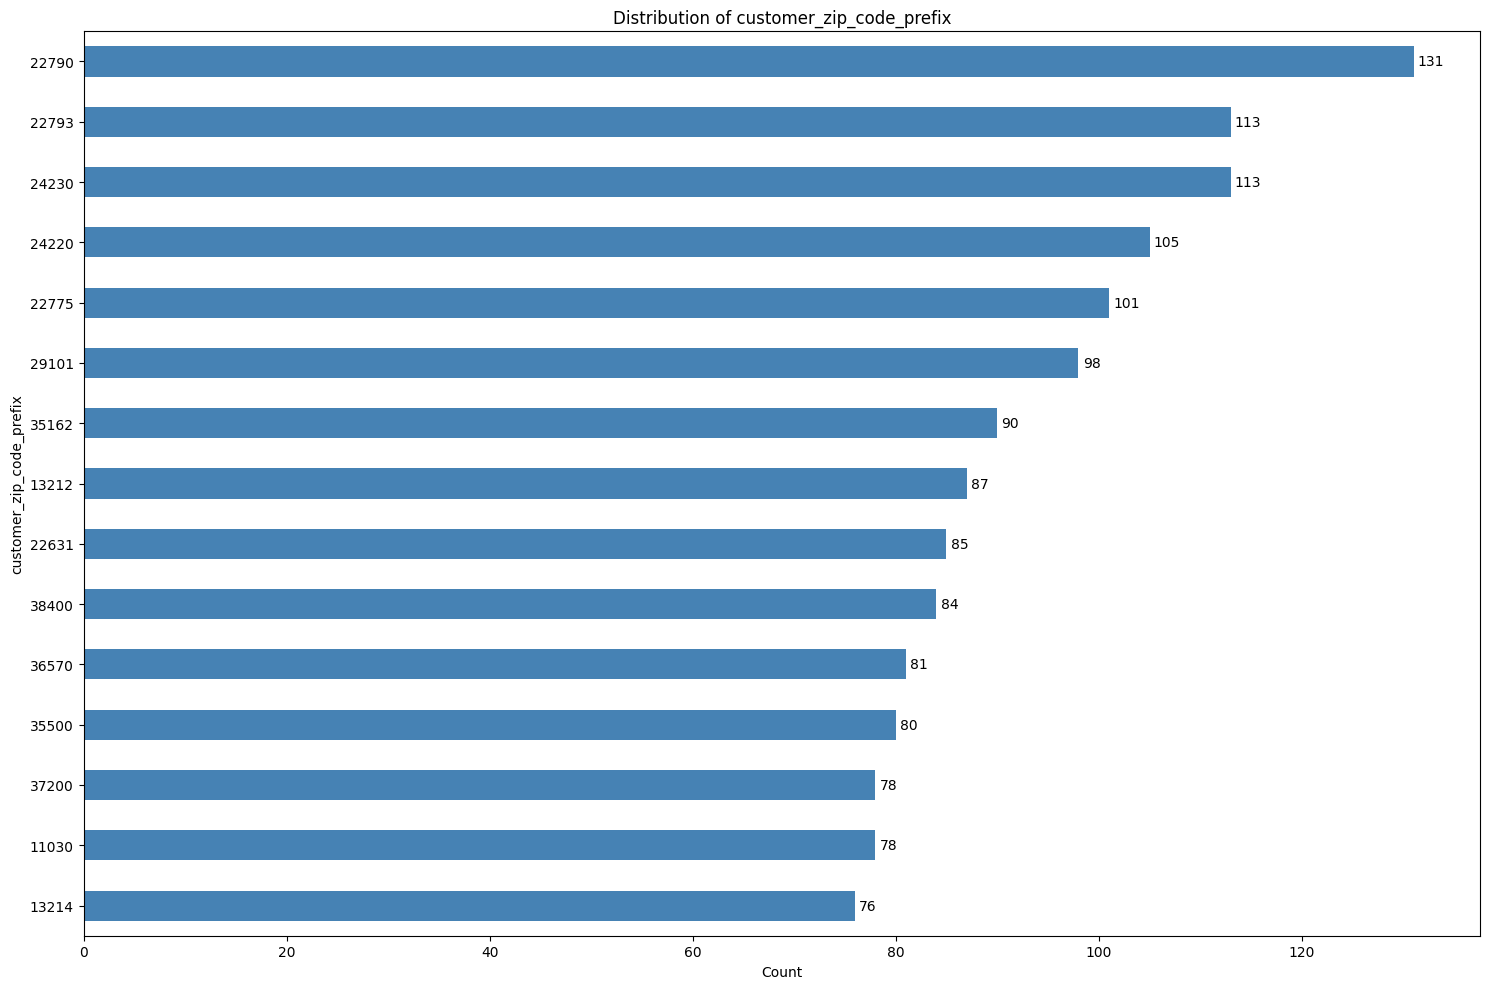

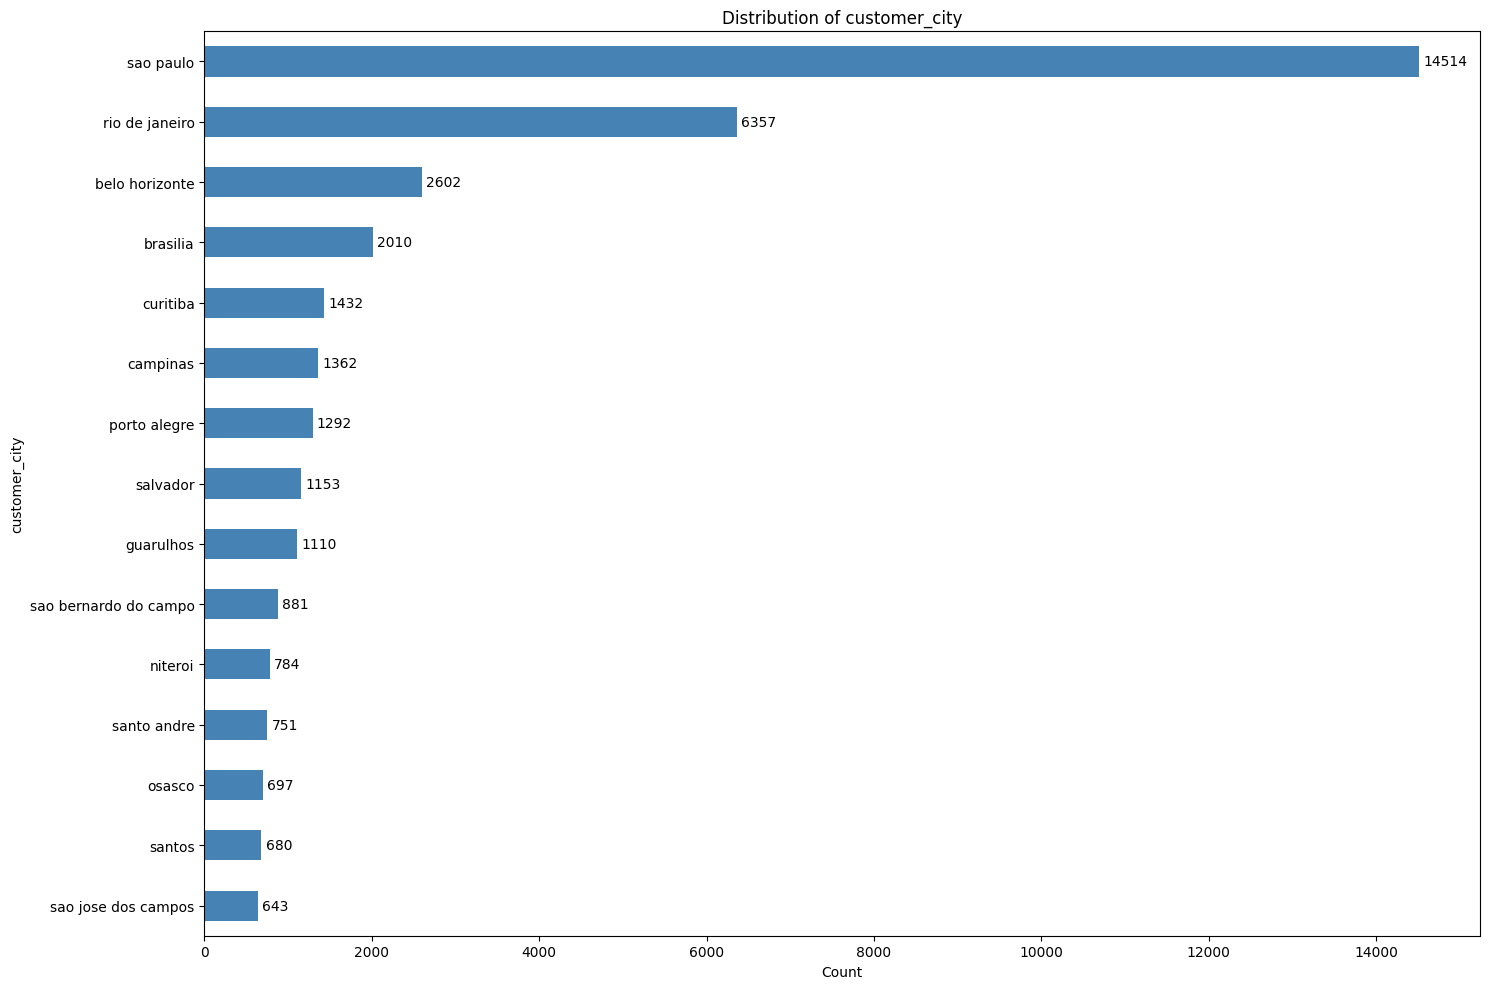

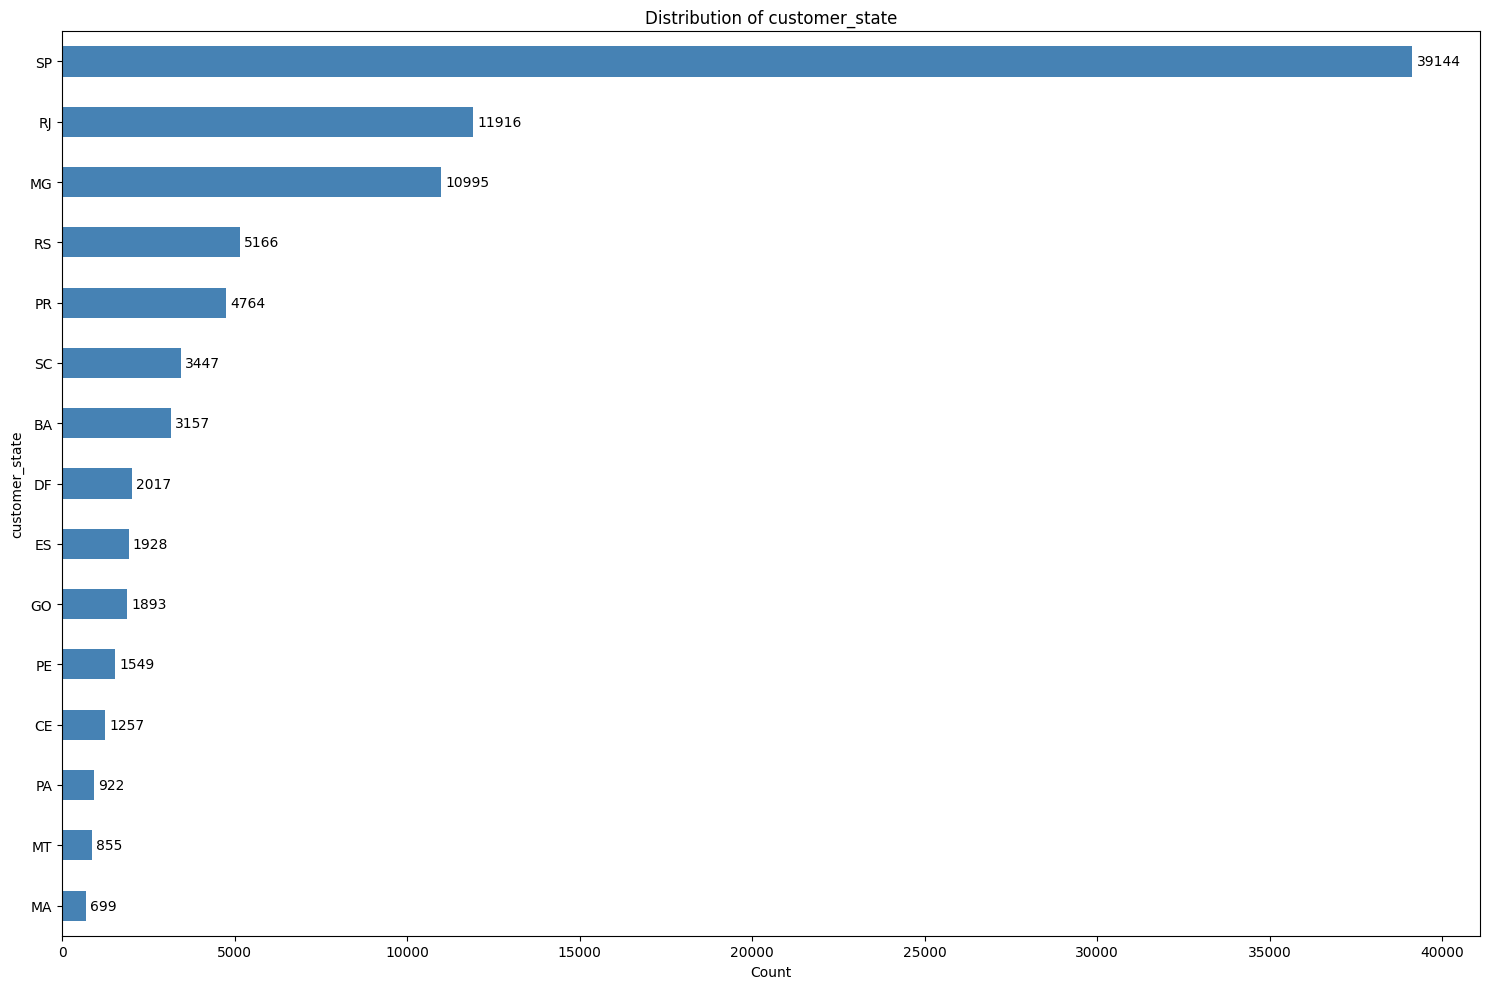

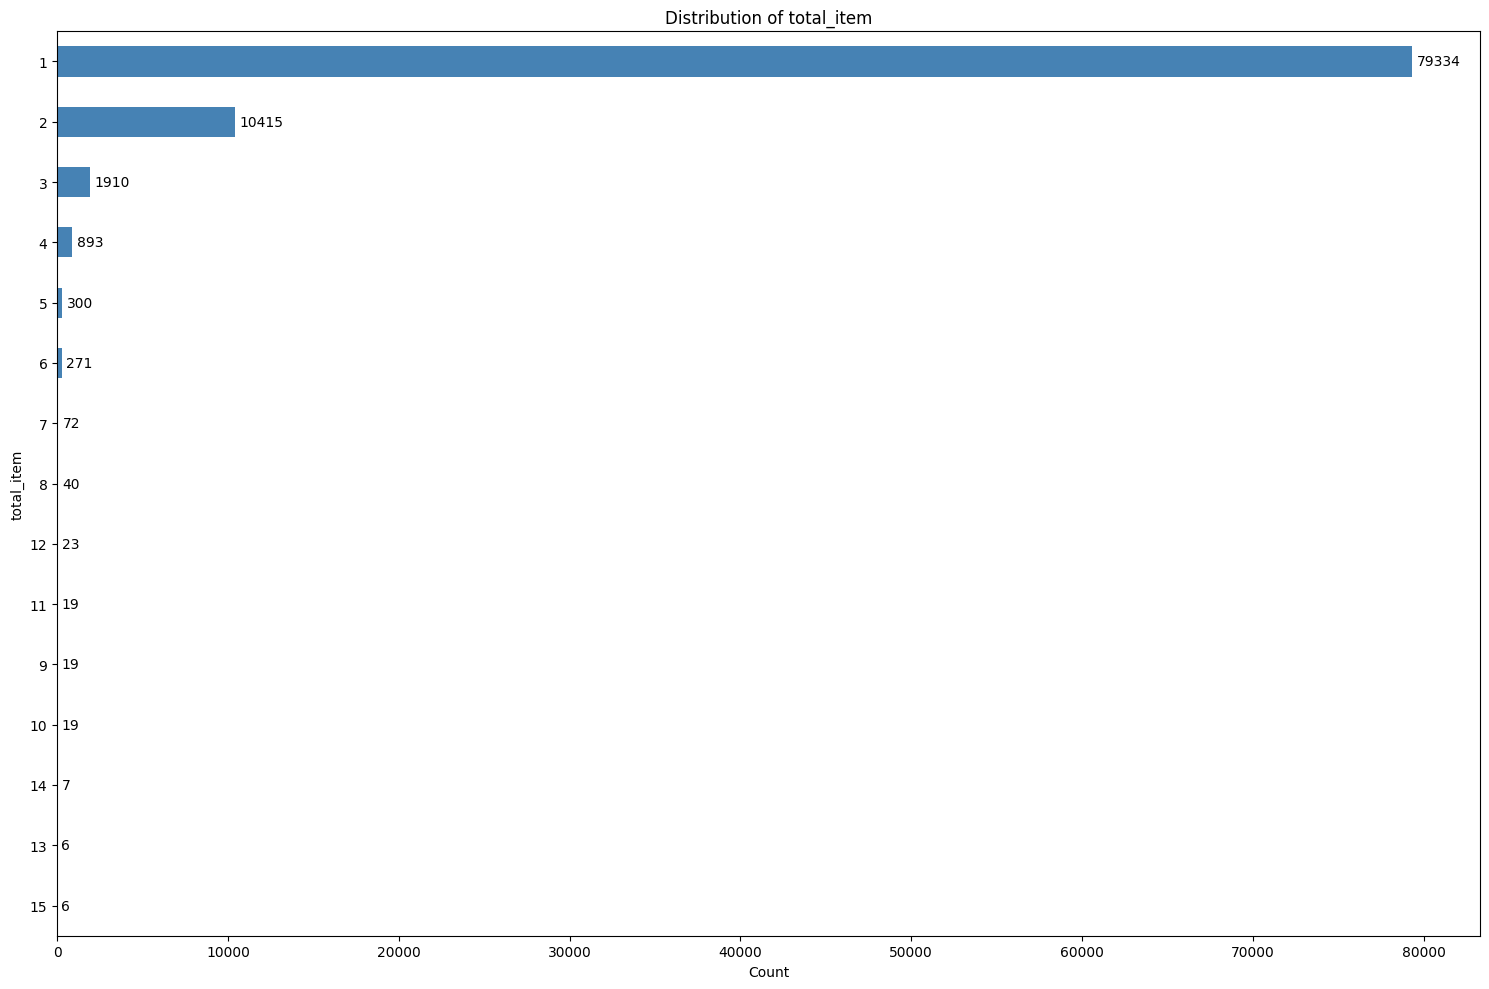

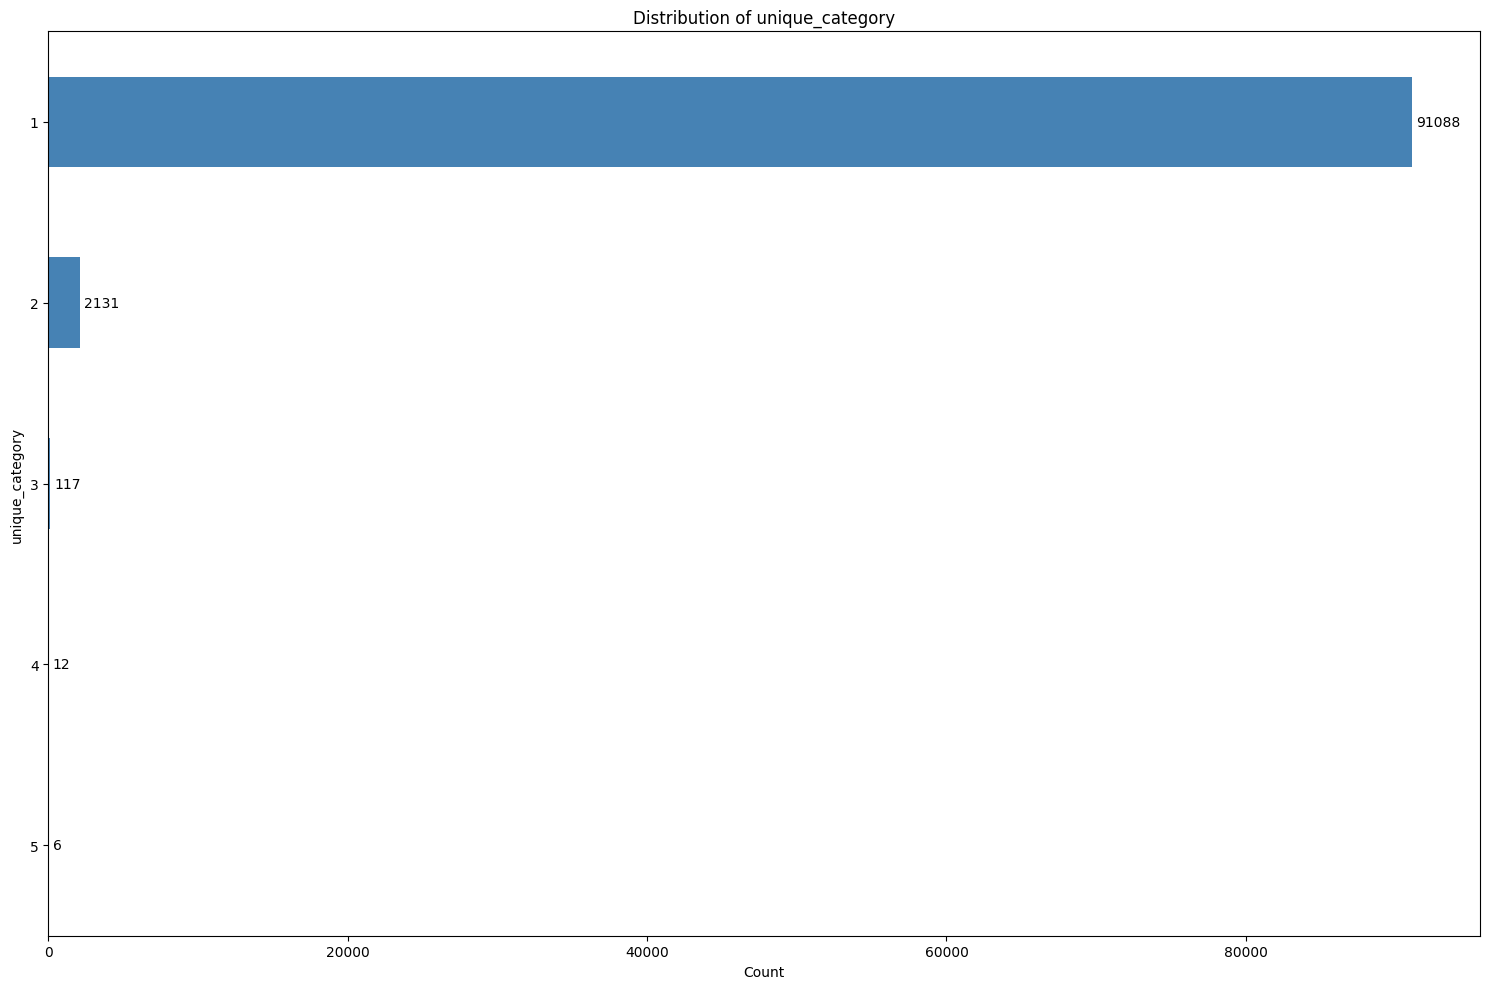

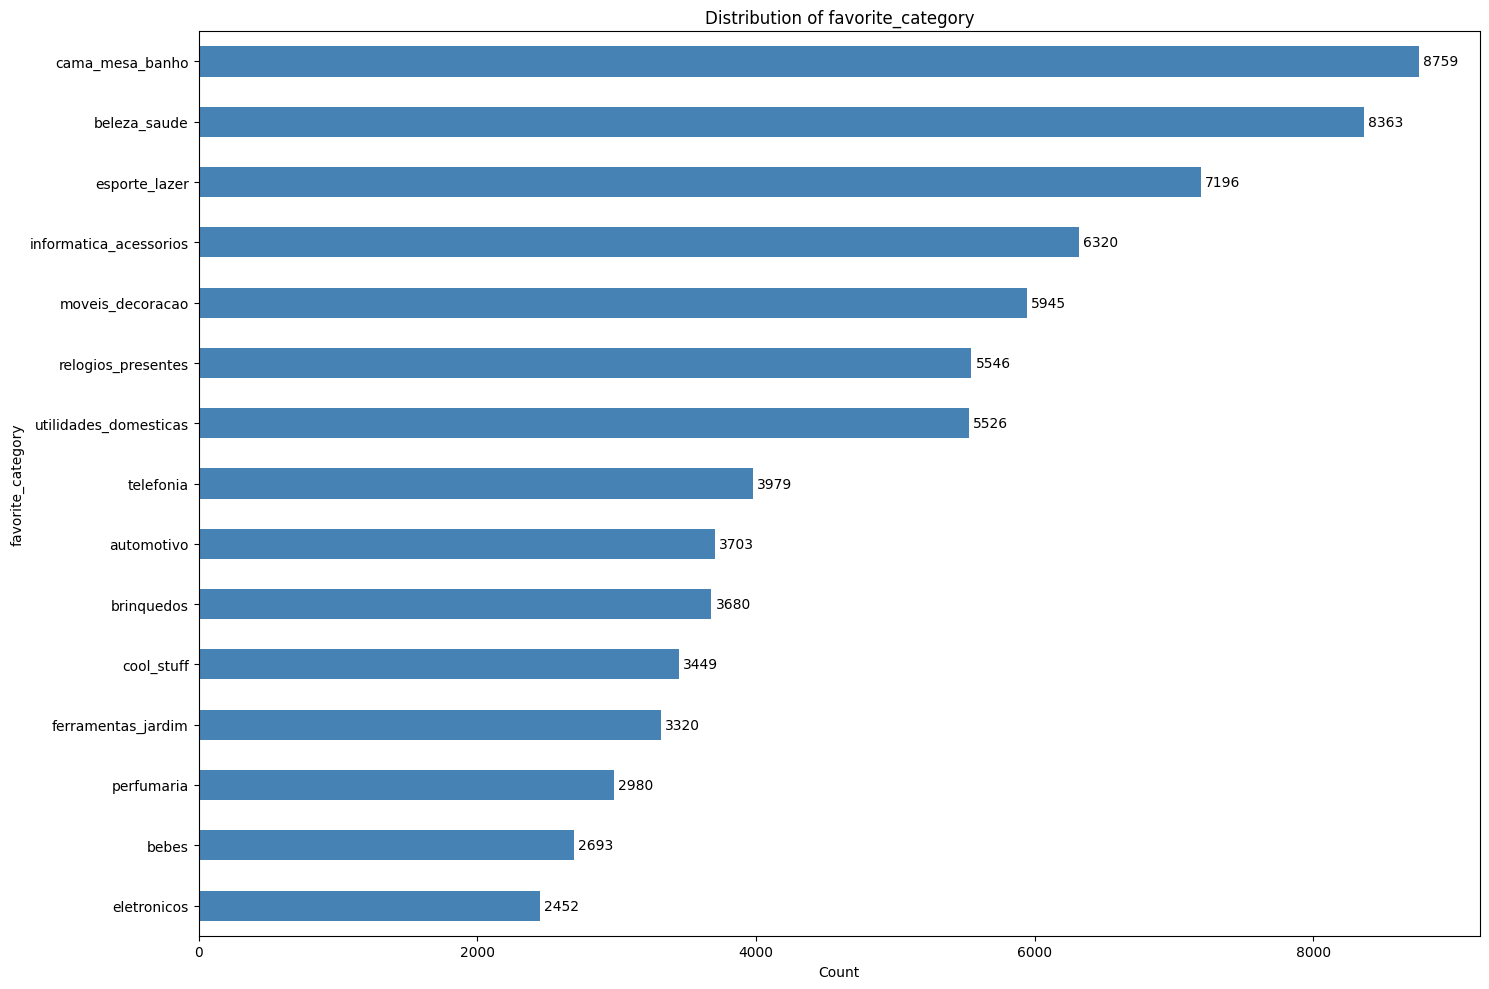

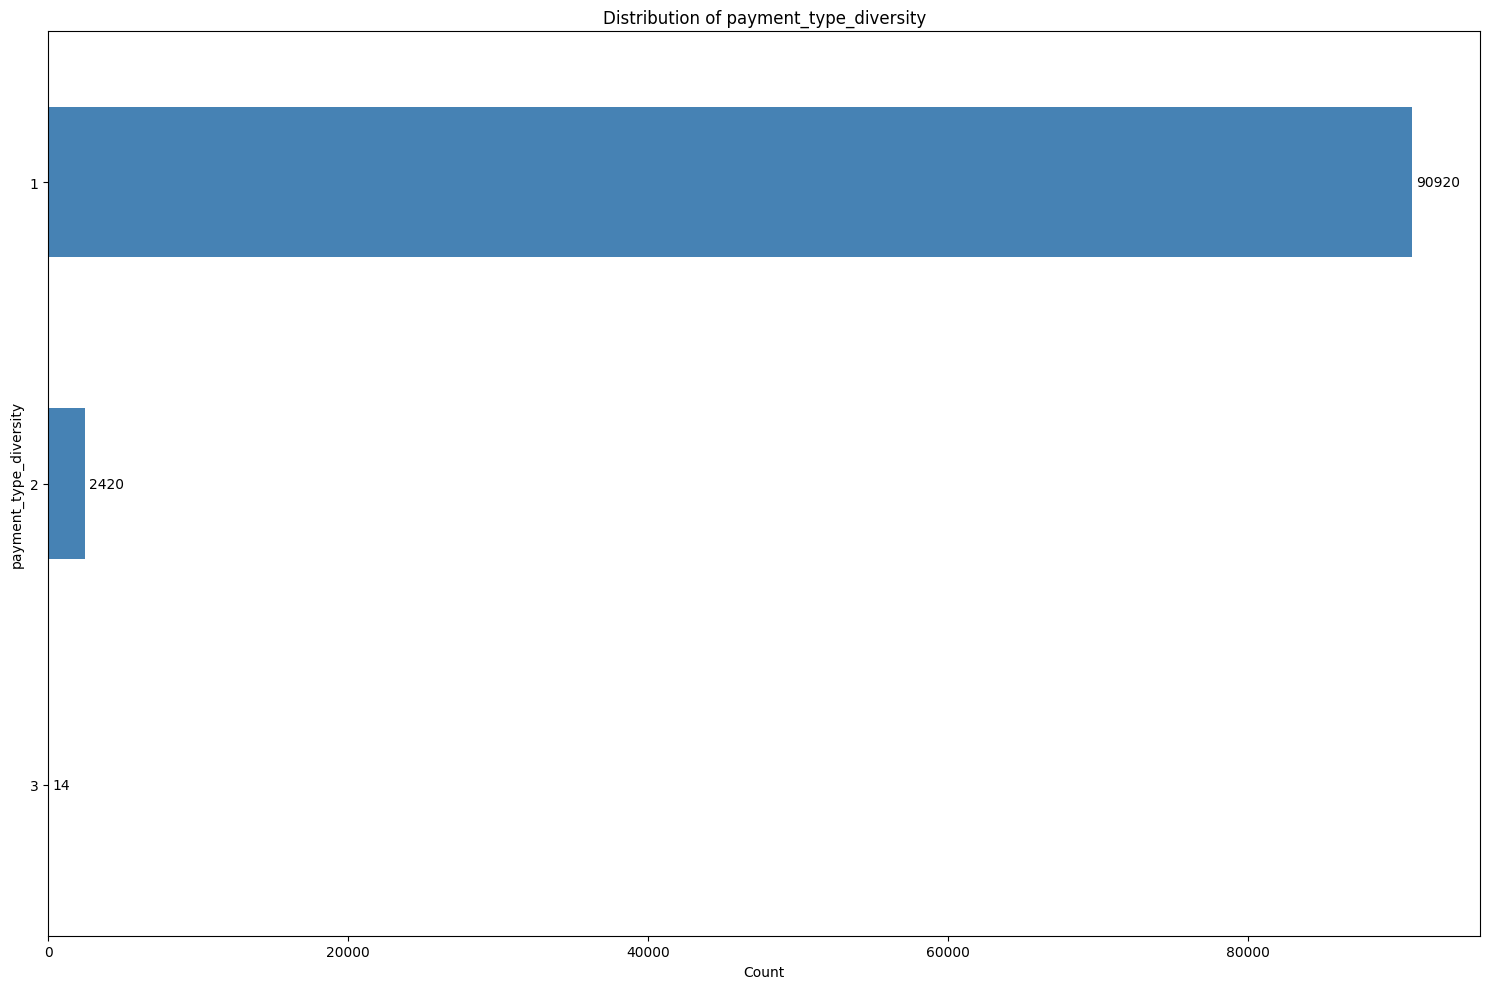

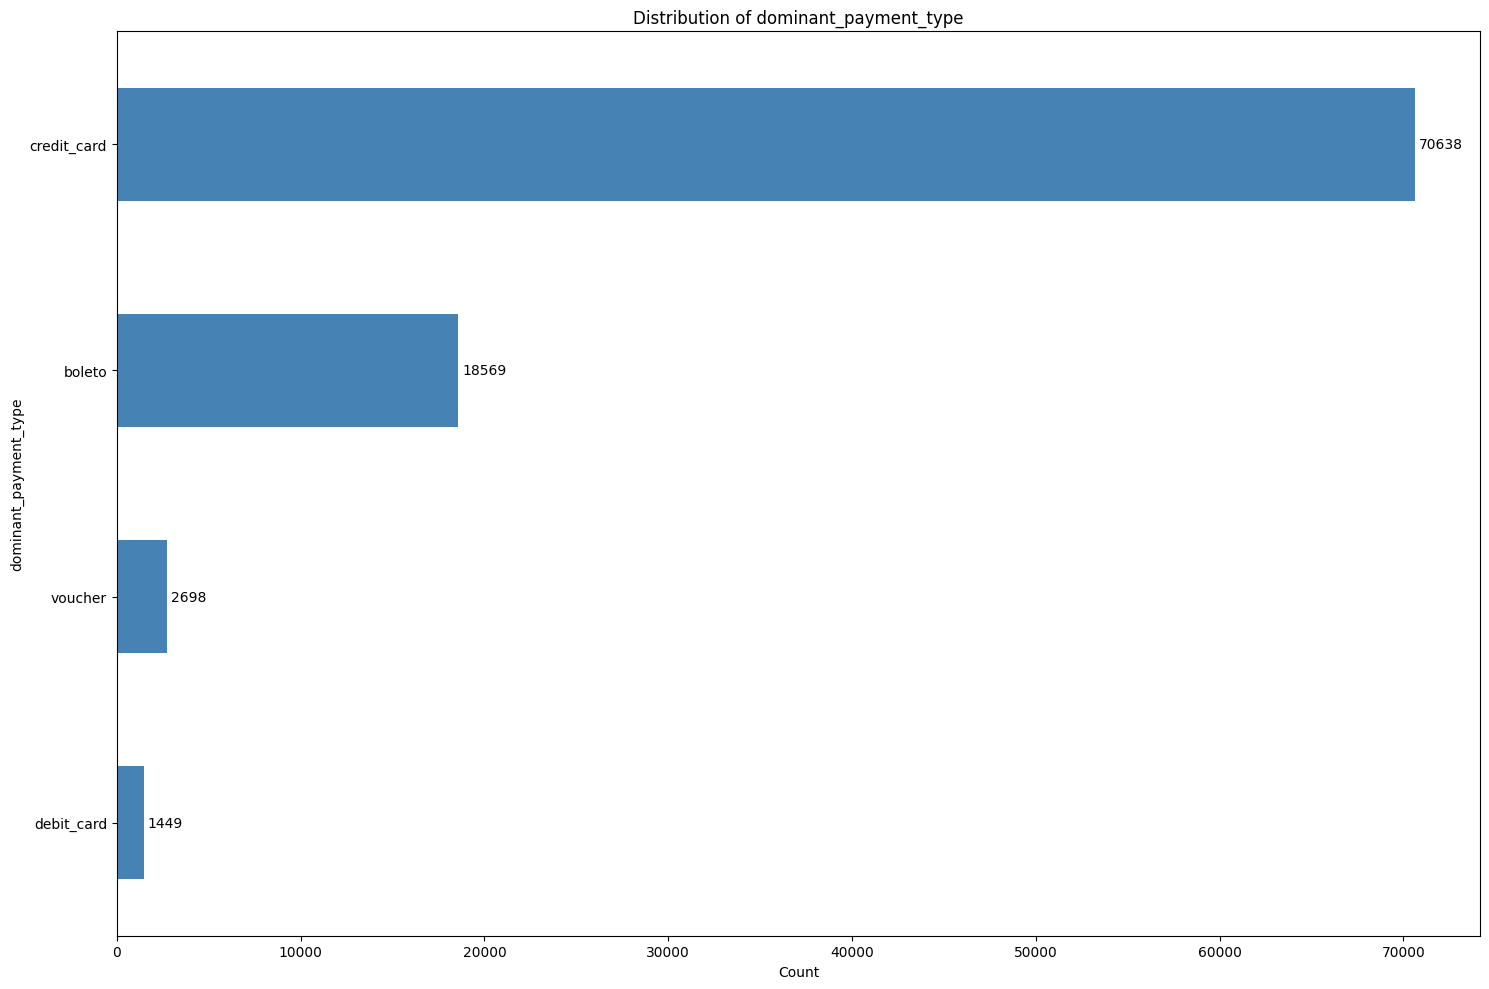

In [46]:
import matplotlib.pyplot as plt

cols = [
    'frequency',
    'customer_zip_code_prefix',
    'customer_city',
    'customer_state',
    'total_item',
    'unique_category',
    'favorite_category',
    'payment_type_diversity',
    'dominant_payment_type',
]

for col in cols:
    plt.figure(figsize=(15, 10))
    
    ax = olist_customers[col].value_counts().head(15).sort_values().plot(
        kind='barh',
        color='steelblue'
    )

    # thêm số lên bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)

    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Numerical data

Nhận xét: 

Recency: Phân bố khá rộng, đa số khách hàng quay lại mua trong khoảng 100-400 ngày gần nhất.

Monetary: Rất lệch phải mạnh. Hầu hết khách hàng chi tiêu ở mức thấp, chỉ một tỷ lệ nhỏ chi tiêu rất cao.

Avg_delivery_days: Phần lớn đơn hàng giao trong vòng 0-30 ngày, tập trung mạnh quanh 10-20 ngày. Hiệu suất giao hàng tổng thể khá tốt.

Avg_shipping_delay: Hầu hết đơn hàng giao đúng hạn hoặc sớm (tập trung quanh 0 và âm). Tuy nhiên vẫn có một lượng nhỏ delay khá lớn (>50 ngày)

Late_delivery_ratio: Peak rất mạnh ở 0 → Hầu hết đơn hàng không bị trễ. Nhưng có một nhóm nhỏ (~1%) luôn bị trễ (peak ở 1.0).

Avg_freight_ratio (phí vận chuyển/tổng giá trị): Phân bố lệch phải, đa số ở mức 0.1-0.3. Phí ship chiếm tỷ lệ hợp lý, nhưng một số đơn hàng phí ship chiếm quá cao so với giá trị sản phẩm.

Avg_freight_value (giá trị phí vận chuyển trung bình): Đa số đơn hàng có phí ship thấp (<50), rất ít đơn có phí ship cao.

Avg_estimated_gap (chênh lệch giữa thời gian dự kiến và thực tế): Tập trung quanh 10-30, cho thấy thời gian giao hàng thực tế thường lâu hơn dự kiến một khoảng đáng kể.

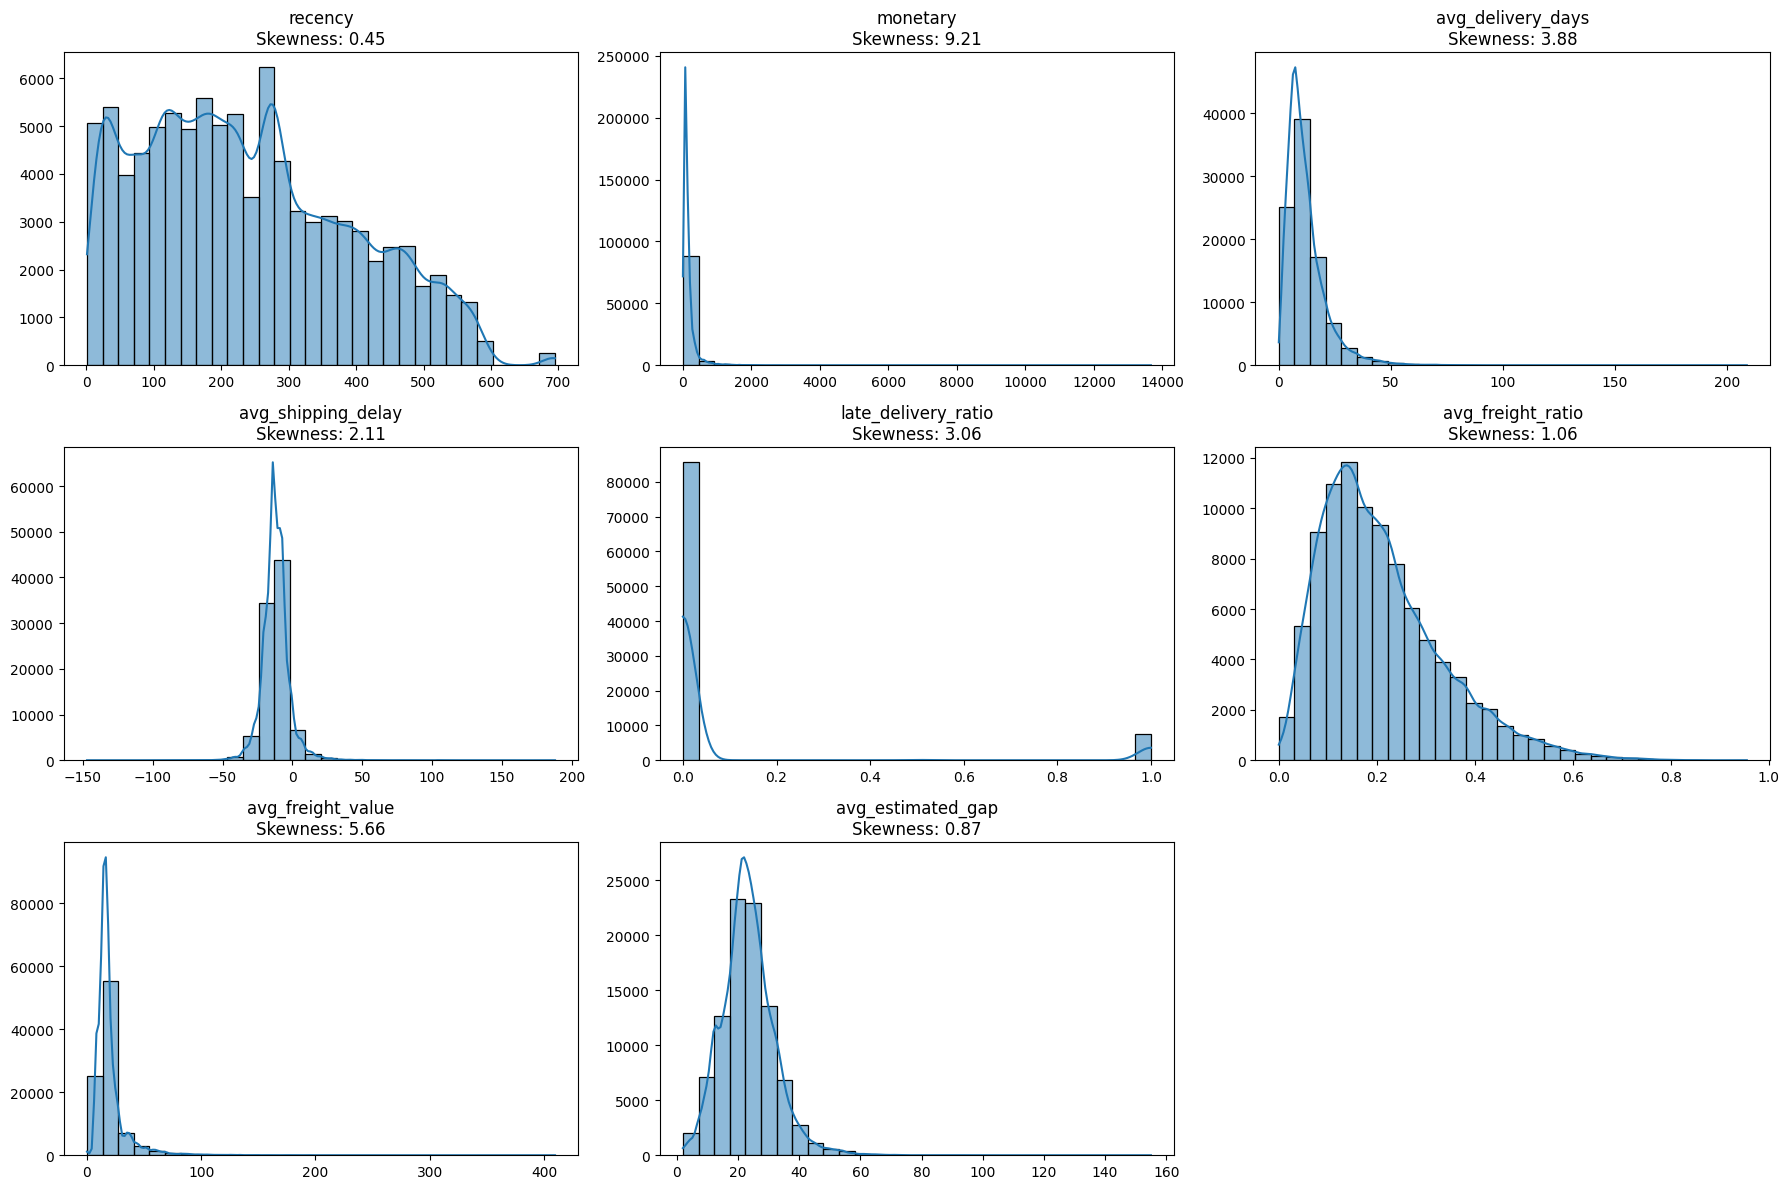

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'recency',
    'monetary',
    'avg_delivery_days',
    'avg_shipping_delay',
    'late_delivery_ratio',
    'avg_freight_ratio',
    'avg_freight_value',
    'avg_estimated_gap'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(cols):
    plt.subplot(3, 3, i + 1)

    # Tính skewness
    skewness = olist_customers[col].skew()

    sns.histplot(
        olist_customers[col],
        bins=30,
        kde=True
    )

    plt.title(f'{col}\nSkewness: {skewness:.2f}')
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

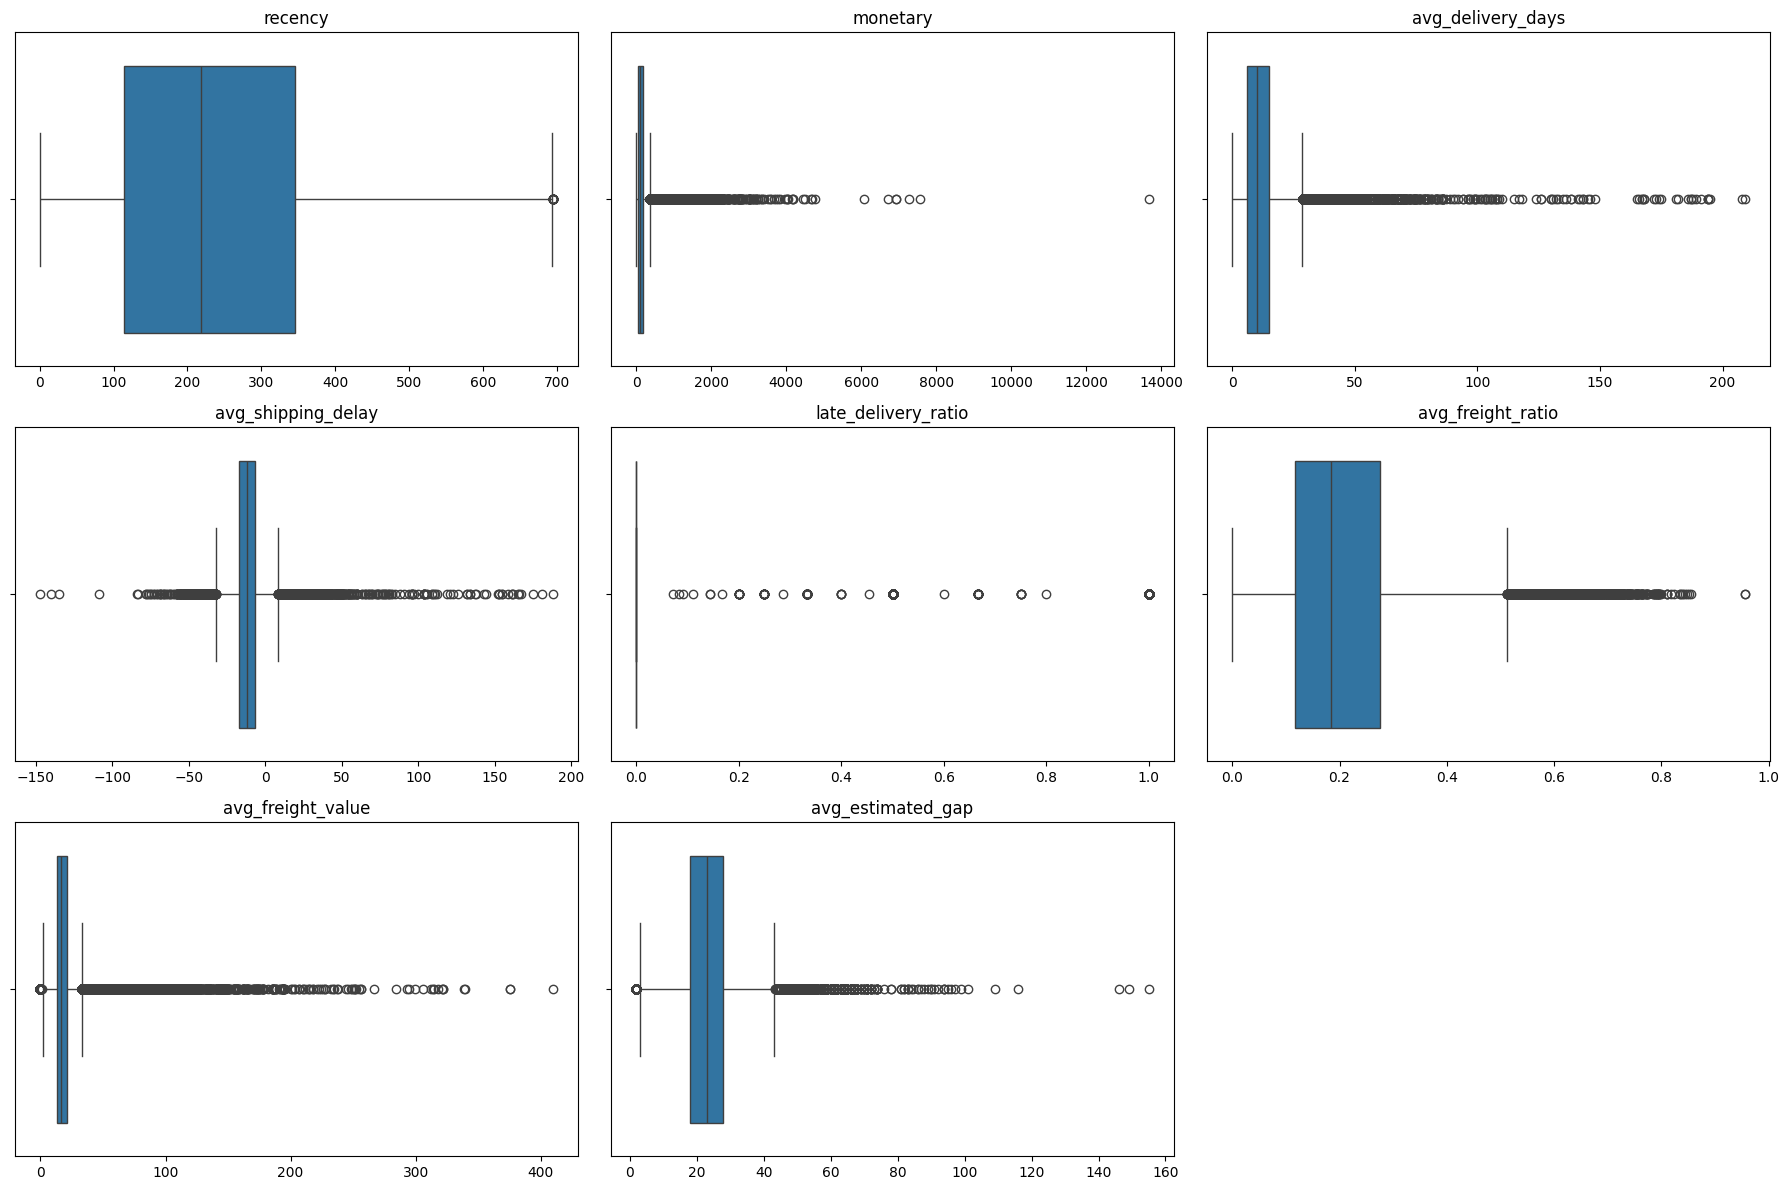

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'recency',
    'monetary',
    'avg_delivery_days',
    'avg_shipping_delay',
    'late_delivery_ratio',
    'avg_freight_ratio',
    'avg_freight_value',
    'avg_estimated_gap'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(cols):
    plt.subplot(3, 3, i + 1)

    sns.boxplot(
        x=olist_customers[col]
    )

    plt.title(col)
    plt.xlabel("")

plt.tight_layout()
plt.show()